Exploring and learning Neural Network fundamentals utilizing the PyTorch Tutorials through Pytorch.org.

<h2>Tensors</h2>

In [109]:
#Standard Imports
import torch
import numpy as np

<h3>Tensors Introduction</h3><p>Specialized data structure similiar to arrays. Used for encoding inputs and outputs of a model.</p>

In [110]:
#Initilize from data
data = [[1,2],[3,4]]
x_data = torch.tensor(data)
print(f"Data:  \n{x_data}\n")

#Initilize from NumPy
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(f"NumpPy:  \n{x_np}\n")

#Initilize from another tensor
x_ones = torch.ones_like(x_data) # retains datatype
print(f"Ones Tensor: \n{x_ones}\n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides datatype
print(f"Random Tensor: \n{x_rand}\n")


Data:  
tensor([[1, 2],
        [3, 4]])

NumpPy:  
tensor([[1, 2],
        [3, 4]])

Ones Tensor: 
tensor([[1, 1],
        [1, 1]])

Random Tensor: 
tensor([[0.3145, 0.4553],
        [0.7660, 0.3374]])



<h3>Tensor Operations</h3>

In [111]:
#NumPy-like indexing + slicing
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [112]:
#Concatenate Tensors
t1 = torch.cat([tensor,tensor,tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [113]:
#Arithmetic Operations

#Matrix Multiplication (y1, y2, y3 all equivalent)
y1 = tensor @ tensor.T #tensor.T returns transpose of tensor
y2 = tensor.matmul(tensor.T)

y3= torch.rand_like(y1) #random tensor with shape of y1
torch.matmul(tensor,tensor.T,out=y3) #y3 stores result of dot product

#Element-wise product (z1, z2, z3 all equivalent)
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor) #random tensor with shape of z1
z3 = torch.mul(tensor,tensor,out=z3) #z3 stores result of element-wise product

In [114]:
#Single element tensor and conversion
agg = tensor.sum() # aggregating all values of a tensor
agg_item = agg.item()
print(agg, type(agg)) # Single-element
print(agg_item, type(agg_item))# Converted

tensor(12.) <class 'torch.Tensor'>
12.0 <class 'float'>


<h3>Bridging with NumPy</h3>
<p>Tensors on the CPU (as opposed to on an accelorator) can share memory locations with NumPy arrays.</p>

In [115]:
#Tensor to NumPy
t = torch.ones(5) #array of five 1s
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

#changing one changes both
t.add_(1) #_ denotes in-place operation that stores result into operand, discouraged 
print("value added: 1")
print(f"t: {t}")
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]
value added: 1
t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [116]:
#Numpy to  Tensor
n = np.ones(5)
t= torch.from_numpy(n)
print(f"t: {t}")
print(f"n: {n}")

np.add(n,1,out=n)
print("value added: 1")
print(f"t: {t}")
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.], dtype=torch.float64)
n: [1. 1. 1. 1. 1.]
value added: 1
t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


<h2>Datasets and DataLoaders</h2>

<h3>Loading a Dataset</h3>

In [117]:
#Loads the Fashion-MNIST dataset from TorchVision.
#Consists of 60,000 training and 10,000 test examples of
#greyscale images and a label from one of 10 classes

import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

#Loads FashionMNIST Dataset with parameters
training_data = datasets.FashionMNIST(
    root="data", #path where the train data is stored
    train=True, #specifies training set
    download=True, #downloads from interenet if not available
    transform=ToTensor() #feature and label transformations
)

#Parameters are same as above
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

<h3>Iterating & Visualizing Dataset</h3>

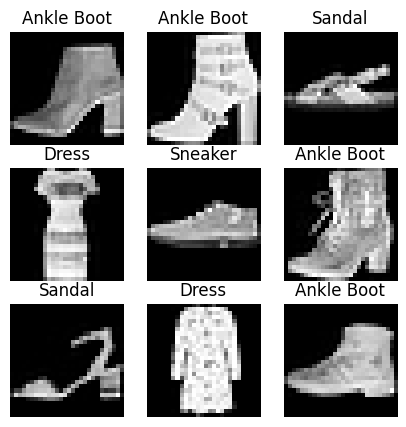

In [118]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(5, 5)) #figure for displaying examples in data
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item() #grabbing index of random data
    img, label = training_data[sample_idx] #tuple of the image and label we grabbed
    figure.add_subplot(rows, cols, i) #section of figure we are adding to
    plt.title(labels_map[label]) #title determined from label_map 
    plt.axis("off") #removes axis from plots (not needed for images)
    plt.imshow(img.squeeze(), cmap="gray") #fits image to subplot and makes it a greyscale image
plt.show()

<h3>Creating Custom Dataset</h3>

<p>Must implement __init__, __len__, and __getitem__. This implementation has the Fashion MNIST images stored in a directory (img_dir) and labels stored in a separete CSV file (annotations_file).</p>

In [119]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    """ __init__ is ran once during instantiation. Initilizes directory for images, annotaions,
        and both transforms.
    """
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
    
    """ __len__ returns number of samples in dataset
    """
    def __len__(self):
        return len(self.img_labels)

    """ __getitem__ loads and returns a sample given an index, including locating the item
        in the disk, converting it to a tensor using decode_image
    """
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

<h3>Preparing data for training with DataLoaders</h3>

<p>DataLoaders are iterables that abstract the training process by passing samples in batches, shufffling the data at every epoch, and utilizing Python's mutliprocecessing to speed up data retreival.</p>

In [120]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=True)

Feature batch shape: torch.Size([128, 1, 28, 28])
Labels batch shape: torch.Size([128])


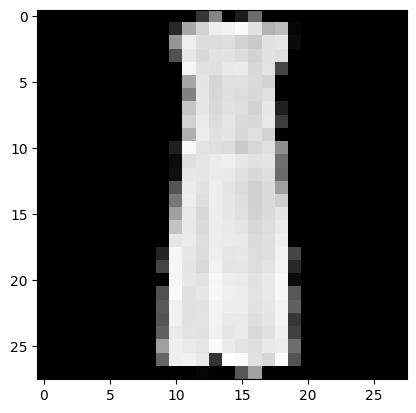

Label: 3


In [121]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [122]:
print(training_data[0][0].size())

torch.Size([1, 28, 28])


<h2>Transforms</h2>

<p>Data that is not fully processed for the training algorithm can be processed using <em>transform</em> to modify features and <em>target_transform</em> to modify labels.</p>

In [123]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

<h3>ToTensor()</h3>

<p>Converts a PIL Image or NumPy ndarray into a FloatTensor, and scales image pixel intensity to a range of [0, 1.]</p>

<h3>Lambda Transforms</h3>

<p>Applies user defined lambda functions. The example below shows a lambda function that turns the integer into a one-hot encoded tensor. It first creates a zero tensor of size 10 (the number of labels in our dataset) and calls scatter_ which assigns a value=1 on the index as given by the label y</p>

In [124]:
target_transform = Lambda(lambda y: torch.zeros(
    10, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1))

<h2>Build the Neural Network</h2>

<p>The torch.nn namespace provides all the building blocks needed to build a neural network. Every module in PyTorch subclasses the nn.Module</p>

In [125]:
##Imports for building network
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

<h3>Get Device for Training</h3>

<p>Models should be trained on an accelerator for efficiency, such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available it will be used, otherwise the CPU will be used.</p>

In [126]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
##Outputs current accelerator or CPU if none

Using cuda device


<h3>Define the Class</h3>

<p>Network classes are subclassed by nn.Module. The layers are initialized through the parent classes __initi__. Every nn.Module subclass implements the operations on input data (reLu, Linear Regression, Sigmoid, etc) in the forward method. <strong>DO NOT CALL model.forward() DIRECTLY</strong></p>

In [144]:
# Network Implementation
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
##Instance of Network is created and moved to the accelerator
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


<p>Calling the model on the input returns a 2-dimensional tensor with dim=0 corresponding to each output of 10 raw predicted values for each class, and dim=1 corresponding to the individual values of each output. The prediction probabilities are found by passing it through an instance of the nn.Softmax module.</p>

In [153]:
X = torch.rand(3, 28, 28, device=device) #create a random tensor of given dimensions
logits = model(X) #Pass tensor to model object
pred_probab = nn.Softmax(dim=1)(logits) #Predictions of each individual output
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([4, 4, 4], device='cuda:0')


<h3>Model Layers</h3>

<p>Illustration of the layers in the FashionMNIST model using a minibatch of 3 images of size 28x28</p>

In [129]:
input_image = torch.rand(3,28,28) #Sample minibatch
print(input_image.size())

torch.Size([3, 28, 28])


<h3>nn.Flatten</h3>

<p> Converts images into contigous arrays of 784 pixel values. dim=0 maintains the dimensions of the mini batch </p>

In [130]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


<h3>nn.Linear</h3>

<p>Module that applies a linear transformation on the input using its stored weights and biases</p>

In [131]:
layer1 = nn.Linear(in_features=28*28, out_features=20) #Create specifications for hidden layer
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


<h3>nn.Relu</h3>

<p>One of the non-linear activations used to introduce nonlinearity into the model after linear transformations.</p>

In [132]:
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")
#ReLu - Negative values -> 0, otherwise unchanged

Before ReLU: tensor([[-5.6630e-01, -2.9091e-02,  1.0834e-01, -6.5342e-02,  2.8421e-01,
         -1.6932e-01, -9.5851e-02, -2.1891e-01,  3.2709e-02, -1.2356e-01,
         -2.5404e-01, -3.4265e-01,  4.0818e-01, -2.4293e-01,  1.8481e-01,
          3.0569e-01, -3.3371e-01, -1.5318e-02,  1.0467e+00,  2.4942e-01],
        [-2.0091e-01, -1.0049e-02,  1.0086e-02, -1.2685e-01,  3.3247e-02,
         -5.8027e-02, -7.6808e-02, -3.1839e-01, -3.3790e-02, -4.4163e-01,
         -2.0453e-01, -2.2636e-01,  7.5912e-01, -5.4022e-01, -1.2599e-01,
          4.5181e-01, -2.5517e-01,  1.0661e-01,  1.1088e+00,  1.5682e-01],
        [-7.4011e-01, -1.6106e-02,  5.8818e-02, -5.3189e-02, -7.1332e-02,
         -1.2248e-01, -9.0192e-04,  1.2865e-01,  1.5591e-01, -6.3592e-01,
         -6.9276e-02, -4.3481e-01,  3.0738e-01, -4.3416e-01,  1.2760e-01,
          2.5360e-01,  3.2015e-01, -7.3123e-02,  7.3773e-01,  4.2312e-01]],
       grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0000, 0.1083, 0.0000, 0.2842,

<h3>nn.Sequential</h3>

<p>An ordered container of modules. Data is passed through all the modules in the same order defined.</p>

In [133]:
seq_modules = nn.Sequential(
    flatten, #nn.Flatten
    layer1, #nn.Linear for 28*28 in and 20 out
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

<h3>nn.Softmax</h3>

<p>The last linear layer of the neural network returns logits - raw values in [-infty, infty] - which are passed to the nn.Softmax module. The logits are scaled to values [0, 1] representing the model’s predicted probabilities for each class. dim parameter indicates the dimension along which the values must sum to 1.</p>

In [134]:
#Before softmax
print(logits)
#after softmax
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
print(pred_probab)

tensor([[ 0.0136,  0.1662,  0.1726,  0.1777,  0.0221,  0.0941, -0.1883,  0.3140,
          0.3669,  0.0586],
        [-0.0488,  0.1054,  0.0472,  0.2193,  0.1521,  0.0288, -0.0586,  0.2012,
          0.2889, -0.1000],
        [-0.0928,  0.0509, -0.0429,  0.1991,  0.0646,  0.1558, -0.0650,  0.1438,
          0.3281, -0.0811]], grad_fn=<AddmmBackward0>)
tensor([[0.0889, 0.1036, 0.1043, 0.1048, 0.0897, 0.0964, 0.0727, 0.1201, 0.1266,
         0.0930],
        [0.0869, 0.1014, 0.0957, 0.1137, 0.1063, 0.0939, 0.0861, 0.1116, 0.1218,
         0.0826],
        [0.0845, 0.0976, 0.0889, 0.1132, 0.0990, 0.1084, 0.0869, 0.1071, 0.1288,
         0.0855]], grad_fn=<SoftmaxBackward0>)


<h3>Model Parameters</h3>

<p>Many layers inside a neural network are parameterized, i.e. have associated weights and biases that are optimized during training. Subclassing nn.Module automatically tracks all fields defined inside the model object, and makes all parameters accessible using the model’s parameters() or named_parameters() methods.</p>

In [135]:
#Iterate through parameter and print size + values
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0008,  0.0324,  0.0013,  ...,  0.0007, -0.0253, -0.0318],
        [ 0.0311, -0.0130,  0.0110,  ..., -0.0189, -0.0043, -0.0307]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([-0.0278, -0.0300], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0146, -0.0361, -0.0315,  ...,  0.0132,  0.0111, -0.0254],
        [ 0.0011,  0.0177, -0.0402,  ..., -0.0389,  0.0016, -0.0095]],
       device='cuda:0', grad_fn=<Sl

<p>Note: Activation function ReLu does not have biases or weights associated with it.<p>

<h2>Autograd</h2>

<p>Neural networks are most frequently trained using back propagation, in which parameters are adjusted according to the graident of the loss function iwht respect to the given parameter. These gradients are computed through the built in differenetiation engine torch.autograd. A simple one-layer neural network may be defined in PyTorch in the following manner:</p>

In [136]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True) #can be set now, or with the .requires_grad_(True) method
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y) #Computes loss based on logits vs expected

<h3>Computing Gradients</h3>

<p>To optimize weights of parameters in the neural network, the derivatives of the loss function with respect to parameters must be computed
under some fixed values of x and y. To compute those derivatives, call loss.backward(), and then retrieve the values from w.grad and b.grad</p>

In [137]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.0539, 0.2217, 0.1395],
        [0.0539, 0.2217, 0.1395],
        [0.0539, 0.2217, 0.1395],
        [0.0539, 0.2217, 0.1395],
        [0.0539, 0.2217, 0.1395]])
tensor([0.0539, 0.2217, 0.1395])


<h2>Optimizing Model Parameters</h2>

<p>Once a model is built and data is found, the network can be trained, validated, and tested by optimizing its parameters through an iterative process. The model first guesses, calculates the error in the guess (loss), collects the deratives of the error with respect to the parameters, and optimizes the parameters using gradient descent</p>

<p>Math behind back propagation: Series of chain rule expressions which gives the derivatives of each component in the gradient that help minimize the cost of the network. How do minimal changes in the parameters affect the accuracy of the model, and making minimal changes to increase effieciency</p>

In [138]:
#Previous Code from Datasets.

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=128)
test_dataloader = DataLoader(test_data, batch_size=128)

#the Network we defined earlier
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

<h3>Hyperparameters</h3>

<p>The following parameters are used to control the optimization process.<p>
<ul>
    <li><strong>Number of Epochs</strong> - times to iterate over dataset</li>
    <li><strong>Batch size</strong> - how many data samples are propogated through network before parameters are updated</li>
    <li><strong>Learning Rate</strong> - How much to update model parameters. Smaller value = slow learning, higher values = unpredictable behavior</li>
</ul>

In [139]:
epochs = 5
batch_size = 64
learning_rate = 1e-3

<h3>Optimization Loop</h3>

<p>Broken into two parts:</p>
<ul>
    <li><strong>Train Loop</strong> - iterate through training data to optimize parameters</li>
    <li><strong>Validation/Test Loop</strong> - iterate over test dataset to check for improvement</li>
</ul>

In [140]:
# Initialize the loss function for classification
loss_fn = nn.CrossEntropyLoss()

# Optimizer used to adjust model parameters in training step.
# This example uses the SGD optimizer.
# At each iteration, the optimizer is reset to 0, the loss.backwards() call deposits the gradients,
# and optimizer.step() adjusts the parameters based on the gradients collected
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #see Build Neural Network for paramter method call

# Full Implementation of Train / Test Loop

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [141]:
# Exmaple using the FashionMNIST dataset

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.312677  [  128/60000]
loss: 2.287151  [ 6528/60000]
loss: 2.275431  [12928/60000]
loss: 2.269958  [19328/60000]
loss: 2.240239  [25728/60000]
Test Error: 
 Accuracy: 28.9%, Avg loss: 2.235408 

Epoch 2
-------------------------------
loss: 2.239769  [  128/60000]
loss: 2.213056  [ 6528/60000]
loss: 2.202685  [12928/60000]
loss: 2.199031  [19328/60000]
loss: 2.163448  [25728/60000]
Test Error: 
 Accuracy: 45.3%, Avg loss: 2.153791 

Epoch 3
-------------------------------
loss: 2.156319  [  128/60000]
loss: 2.121916  [ 6528/60000]
loss: 2.107296  [12928/60000]
loss: 2.101013  [19328/60000]
loss: 2.058326  [25728/60000]
Test Error: 
 Accuracy: 54.2%, Avg loss: 2.039855 

Epoch 4
-------------------------------
loss: 2.038429  [  128/60000]
loss: 1.991145  [ 6528/60000]
loss: 1.970861  [12928/60000]
loss: 1.956836  [19328/60000]
loss: 1.910465  [25728/60000]
Test Error: 
 Accuracy: 58.3%, Avg loss: 1.880715 

Epoch 5
------------------------

<p> Accuracy of model increased  with first training. Second training results below with an increased epoch </p>

In [142]:
epochs = 15
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 1.027654  [  128/60000]
loss: 0.978718  [ 6528/60000]
loss: 0.990438  [12928/60000]
loss: 0.991505  [19328/60000]
loss: 1.019185  [25728/60000]
Test Error: 
 Accuracy: 65.4%, Avg loss: 1.008474 

Epoch 2
-------------------------------
loss: 0.964711  [  128/60000]
loss: 0.916416  [ 6528/60000]
loss: 0.934270  [12928/60000]
loss: 0.940055  [19328/60000]
loss: 0.969040  [25728/60000]
Test Error: 
 Accuracy: 66.0%, Avg loss: 0.961925 

Epoch 3
-------------------------------
loss: 0.913099  [  128/60000]
loss: 0.865416  [ 6528/60000]
loss: 0.888932  [12928/60000]
loss: 0.898679  [19328/60000]
loss: 0.927785  [25728/60000]
Test Error: 
 Accuracy: 66.5%, Avg loss: 0.923816 

Epoch 4
-------------------------------
loss: 0.870115  [  128/60000]
loss: 0.823099  [ 6528/60000]
loss: 0.851686  [12928/60000]
loss: 0.864841  [19328/60000]
loss: 0.893521  [25728/60000]
Test Error: 
 Accuracy: 67.3%, Avg loss: 0.892158 

Epoch 5
------------------------